# Notebook 06 - GPT-2 Decoder

VisionNarrator | Stage 6

---

## 1. Objective

Replace the scratch caption decoder with a pretrained GPT-2 language model.

                         IMAGE
                           │
                           ▼
                 ┌──────────────────┐
                 │ Fine-tuned ViT   │
                 │ Visual Encoder   │
                 └────────┬─────────┘
                          │
                          ▼
                    Visual Tokens
                          │
                          ▼
                  Visual Projection
                          │
                          ▼
                  GPT-2 Hidden Space
                          │
                          ▼
                 ┌──────────────────┐
                 │       GPT-2      │
                 │   Language Model │
                 └────────┬─────────┘
                          │
                          ▼
                   Token Probabilities
                          │
                          ▼
                    Generated Caption

Setup: imports, configuration, device, paths.

GPT2_MODEL_NAME = gpt2
MAX_TOKENS = 40
BATCH_SIZE = 16
EPOCHS_PHASE1 = 2 (projection only, lr 1e-3)
EPOCHS_PHASE2 = 2 (projection + GPT-2 top 4 blocks, lr 5e-5)
EPOCHS_PHASE3 = 1 (everything, lr 1e-5)
NUM_BEAMS = 5
MAX_NEW_TOKENS = 30
EVAL_NUM_IMAGES = 500

Memory: the 197-token visual prefix runs through all 12 GPT-2 blocks, so BATCH_SIZE stays at 16 on an 8 GB GPU. Close other notebook kernels before training; each one holds GPU memory. Set EPOCHS_PHASE3 = 0 to skip the optional full fine-tuning phase.

LIMIT_TRAIN_BATCHES / LIMIT_VAL_BATCHES cap the batches per epoch. Leave them as None for a real run; set small values (e.g. 200 / 30) for a quick check.


In [1]:
import math
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms as T
from transformers import ViTModel, GPT2LMHeadModel, GPT2TokenizerFast

GPT2_MODEL_NAME = "gpt2"
MAX_TOKENS = 40
DROPOUT = 0.1

BATCH_SIZE = 16
EPOCHS_PHASE1 = 2
EPOCHS_PHASE2 = 2
EPOCHS_PHASE3 = 1
LR_PHASE1 = 1e-3
LR_PHASE2 = 5e-5
LR_PHASE3 = 1e-5
GPT2_TOP_BLOCKS = 4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
WARMUP_FRAC = 0.05

NUM_BEAMS = 5
MAX_NEW_TOKENS = 30
NO_REPEAT_NGRAM = 3

EVAL_NUM_IMAGES = 500
RANDOM_SEED = 42
NUM_WORKERS = 4
LOG_EVERY = 200
LIMIT_TRAIN_BATCHES = None
LIMIT_VAL_BATCHES = None

EFFECTIVE_NUM_WORKERS = NUM_WORKERS
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
USE_AMP = device.type == "cuda"

def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

BASE_DIR = resolve_base_dir()
DATA_DIR = BASE_DIR / "src" / "data"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
MODEL_DIR = BASE_DIR / "src" / "models"
CHECKPOINT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"USE_AMP={USE_AMP}")
print(f"GPT2_MODEL_NAME={GPT2_MODEL_NAME}")
print(f"BATCH_SIZE={BATCH_SIZE} | EPOCHS_PHASE1={EPOCHS_PHASE1} | EPOCHS_PHASE2={EPOCHS_PHASE2} | EPOCHS_PHASE3={EPOCHS_PHASE3}")
print(f"LR_PHASE1={LR_PHASE1} | LR_PHASE2={LR_PHASE2} | LR_PHASE3={LR_PHASE3}")
print(f"LIMIT_TRAIN_BATCHES={LIMIT_TRAIN_BATCHES} | LIMIT_VAL_BATCHES={LIMIT_VAL_BATCHES}")
print(f"EFFECTIVE_NUM_WORKERS={EFFECTIVE_NUM_WORKERS}")
print(f"BASE_DIR: {BASE_DIR}")


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU | 8.6 GB
USE_AMP=True
GPT2_MODEL_NAME=gpt2
BATCH_SIZE=16 | EPOCHS_PHASE1=2 | EPOCHS_PHASE2=2 | EPOCHS_PHASE3=1
LR_PHASE1=0.001 | LR_PHASE2=5e-05 | LR_PHASE3=1e-05
LIMIT_TRAIN_BATCHES=None | LIMIT_VAL_BATCHES=None
EFFECTIVE_NUM_WORKERS=4
BASE_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator


## 2. Why GPT-2?

Notebook 05 decoder
- 4 layers, 7.6M parameters, random initialization
- Vocabulary of 6,619 Flickr30k words, everything else is `<unk>`
- Learned English from 111k captions only → BLEU-4 0.254

GPT-2 (small)
- 12 layers, 124M parameters, pretrained on WebText
- 50,257-token BPE vocabulary, no `<unk>`
- Already knows grammar, phrasing and world knowledge

Design: the projected visual tokens are prepended to the caption embeddings as a visual prefix. GPT-2 attends to the prefix through its normal causal self-attention, so no cross-attention layers are added and the pretrained weights stay intact.

[visual prefix (197)] + [caption tokens]
              ↓
        GPT-2 blocks
              ↓
  logits only at caption positions

Phased training (plan §7):

Phase 1 → projection only (ViT and GPT-2 frozen)
Phase 2 → projection + GPT-2 top 4 blocks
Phase 3 → everything, very small learning rate (optional)


## 3. Load Flickr30k Splits

train.csv
val.csv
test.csv


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train images: {train_df['image'].nunique():,} | rows: {len(train_df):,}")
print(f"Val images:   {val_df['image'].nunique():,} | rows: {len(val_df):,}")
print(f"Test images:  {test_df['image'].nunique():,} | rows: {len(test_df):,}")


Train images: 22,248 | rows: 111,213
Val images:   4,767 | rows: 23,830
Test images:  4,768 | rows: 23,837


## 4. Fine-tuned ViT Visual Encoder

src/models/vit_transfer_captioner.pt (Notebook 05, fine-tuned phase)
      ↓
encoder.vit.* weights → ViTModel

The ViT already adapted to Flickr30k in Notebook 05, so it starts here from those weights, not from the ImageNet checkpoint. Its preprocessing config and the three previous result rows are read from the same file.


In [3]:
TRANSFER_MODEL_PATH = MODEL_DIR / "vit_transfer_captioner.pt"

transfer_ckpt = torch.load(TRANSFER_MODEL_PATH, map_location="cpu")
transfer_config = transfer_ckpt["config"]
previous_results = transfer_ckpt["results"]

VIT_MODEL_NAME = transfer_config["pretrained_model_name"]
IMG_SIZE = transfer_config["img_size"]
IMAGE_MEAN = transfer_config["image_mean"]
IMAGE_STD = transfer_config["image_std"]

vit = ViTModel.from_pretrained(VIT_MODEL_NAME, add_pooling_layer=False)

vit_state = {key[len("encoder.vit."):]: value for key, value in transfer_ckpt["model_state"].items() if key.startswith("encoder.vit.")}
vit.load_state_dict(vit_state, strict=True)
vit = vit.to(device).eval()

def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters())

def count_trainable(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

print(f"Loaded fine-tuned ViT weights: {len(vit_state)} tensors from {TRANSFER_MODEL_PATH.name}")
print(f"Notebook 05 best phase: {transfer_ckpt['best_phase']} | val loss {transfer_ckpt['best_val_loss']:.4f}")
print(f"ViT: {VIT_MODEL_NAME} | {count_parameters(vit):,} parameters")
print(f"IMG_SIZE={IMG_SIZE} | IMAGE_MEAN={IMAGE_MEAN} | IMAGE_STD={IMAGE_STD}")
display(pd.DataFrame(previous_results).T.round(4))


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 4054.58it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.weight | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded fine-tuned ViT weights: 198 tensors from vit_transfer_captioner.pt
Notebook 05 best phase: finetune | val loss 2.6742
ViT: google/vit-base-patch16-224-in21k | 85,798,656 parameters
IMG_SIZE=224 | IMAGE_MEAN=[0.5, 0.5, 0.5] | IMAGE_STD=[0.5, 0.5, 0.5]


,val_loss,perplexity,BLEU-1,BLEU-2,BLEU-3,BLEU-4
Scratch ViT,3.0184,20.4586,0.4904,0.2766,0.1616,0.1005
Frozen ViT + Decoder,2.7380,15.4565,0.6623,0.4671,0.3252,0.2267
Fine-tuned ViT + Decoder,2.6742,14.5012,0.6790,0.4916,0.3528,0.2537


## 5. Preprocessing and DataLoaders

Same 224×224 pipeline as Notebook 05 (mean/std from the ViT checkpoint config), augmentation on train only.

Captions stay raw strings in the batch and are tokenized with the GPT-2 tokenizer in section 7.

`Flickr30kDataset` / `ImageDataset` come from src/vision_data.py so that spawned DataLoader workers can import them. Only the train loader keeps `persistent_workers`.


In [4]:
sys.path.insert(0, str(BASE_DIR))
from src.vision_data import Flickr30kDataset, ImageDataset

train_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
    ]
)

eval_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
    ]
)

def make_loader(dataset, shuffle, persistent):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=EFFECTIVE_NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=persistent and EFFECTIVE_NUM_WORKERS > 0,
        prefetch_factor=4 if EFFECTIVE_NUM_WORKERS > 0 else None,
    )

train_loader = make_loader(Flickr30kDataset(train_df, transform=train_transform), shuffle=True, persistent=True)
val_loader = make_loader(Flickr30kDataset(val_df, transform=eval_transform), shuffle=False, persistent=False)

images, captions = next(iter(train_loader))

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches:   {len(val_loader):,}")
print(f"images.shape: {tuple(images.shape)}")
print(f"pixel range: ({images.min().item():.3f}, {images.max().item():.3f})")
print(f"Sample caption: {captions[0]}")


Train batches: 6,951
Val batches:   1,490
images.shape: (16, 3, 224, 224)
pixel range: (-1.000, 1.000)
Sample caption: the canter in red and gold sings to his church .


## 6. Visual Tokens

(B, 3, 224, 224)
       ↓
Fine-tuned ViT
       ↓
(B, 197, 768)

CLS + 196 patch tokens. All 197 become the visual prefix for GPT-2.


In [5]:
with torch.no_grad():
    visual_tokens = vit(pixel_values=images.to(device)).last_hidden_state

PREFIX_LEN = visual_tokens.shape[1]
VIT_DIM = visual_tokens.shape[2]

print(f"Visual tokens shape: {tuple(visual_tokens.shape)}")
print(f"PREFIX_LEN={PREFIX_LEN} | VIT_DIM={VIT_DIM}")
print(f"Mean token norm: {visual_tokens.norm(dim=-1).mean().item():.2f}")

assert visual_tokens.shape == (images.size(0), 197, 768)


Visual tokens shape: (16, 197, 768)
PREFIX_LEN=197 | VIT_DIM=768
Mean token norm: 5.19


## 7. GPT-2 Tokenizer

Byte-pair encoding, 50,257 tokens, no `<unk>`.

caption + `<|endoftext|>` → input_ids
padding → `<|endoftext|>` with attention_mask 0
labels → input_ids with padded positions set to -100

Every caption is padded to the longest one in its batch, capped at MAX_TOKENS.


In [6]:
tokenizer = GPT2TokenizerFast.from_pretrained(GPT2_MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

EOS_ID = tokenizer.eos_token_id
PAD_ID = tokenizer.pad_token_id

def encode_captions(caption_list, max_tokens=MAX_TOKENS):
    encoded = tokenizer(
        [caption + tokenizer.eos_token for caption in caption_list],
        padding=True,
        truncation=True,
        max_length=max_tokens,
        return_tensors="pt",
    )
    labels = encoded.input_ids.clone()
    labels[encoded.attention_mask == 0] = -100
    return encoded.input_ids, encoded.attention_mask, labels

sample_caption = str(train_df.iloc[0]["caption"])
sample_ids, sample_mask, sample_labels = encode_captions([sample_caption])

token_lengths = [len(ids) for ids in tokenizer(train_df["caption"].astype(str).sample(5000, random_state=RANDOM_SEED).tolist()).input_ids]

print(f"Vocabulary size: {len(tokenizer):,} (Notebook 05 vocabulary: {len(transfer_ckpt['vocab_itos']):,})")
print(f"EOS/PAD id: {EOS_ID}")
print(f"Caption: {sample_caption}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(sample_ids[0])}")
print(f"Ids: {sample_ids[0].tolist()}")
print(f"Decoded: {tokenizer.decode(sample_ids[0], skip_special_tokens=True)}")
print(f"Caption token length (5,000 sample): mean {sum(token_lengths) / len(token_lengths):.1f} | p95 {sorted(token_lengths)[int(0.95 * len(token_lengths))]} | max {max(token_lengths)}")


Vocabulary size: 50,257 (Notebook 05 vocabulary: 6,619)
EOS/PAD id: 50256
Caption: Two young guys with shaggy hair look at their hands while hanging out in the yard .
Tokens: ['Two', 'Ġyoung', 'Ġguys', 'Ġwith', 'Ġsh', 'ag', 'gy', 'Ġhair', 'Ġlook', 'Ġat', 'Ġtheir', 'Ġhands', 'Ġwhile', 'Ġhanging', 'Ġout', 'Ġin', 'Ġthe', 'Ġyard', 'Ġ.', '<|endoftext|>']
Ids: [7571, 1862, 3730, 351, 427, 363, 1360, 4190, 804, 379, 511, 2832, 981, 10938, 503, 287, 262, 12699, 764, 50256]
Decoded: Two young guys with shaggy hair look at their hands while hanging out in the yard .
Caption token length (5,000 sample): mean 13.9 | p95 24 | max 50


## 8. GPT-2 Language Model

GPT2LMHeadModel (small)

wte → 50,257 × 768 token embeddings
wpe → 1,024 × 768 position embeddings
h → 12 causal transformer blocks
ln_f → final LayerNorm
lm_head → 768 → 50,257 (weights tied to wte)

Context of 1,024 positions: 197 prefix + up to 40 caption tokens fits easily.


In [7]:
gpt2 = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME)
gpt2 = gpt2.to(device).eval()

gpt2_config = gpt2.config
GPT2_DIM = gpt2_config.n_embd

print(f"Loaded: {GPT2_MODEL_NAME}")
print(f"Layers: {gpt2_config.n_layer} | Heads: {gpt2_config.n_head} | Hidden: {gpt2_config.n_embd} | Vocab: {gpt2_config.vocab_size:,} | Positions: {gpt2_config.n_positions}")
print(f"GPT-2 parameters: {count_parameters(gpt2):,}")
print(f"wte shape: {tuple(gpt2.transformer.wte.weight.shape)} | lm_head tied to wte: {gpt2.lm_head.weight.data_ptr() == gpt2.transformer.wte.weight.data_ptr()}")
print(f"Blocks: {len(gpt2.transformer.h)}")
print(gpt2.transformer.h[0])


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4660.65it/s]


Loaded: gpt2
Layers: 12 | Heads: 12 | Hidden: 768 | Vocab: 50,257 | Positions: 1024
GPT-2 parameters: 124,439,808
wte shape: (50257, 768) | lm_head tied to wte: True
Blocks: 12
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


## 9. Visual Projection

(B, 197, 768) ViT space
       ↓
Linear(768 → 768) → GELU → Linear(768 → 768) → Dropout
       ↓
(B, 197, 768) GPT-2 hidden space

The only randomly initialized component. Weights start at std 0.02, so the projected prefix begins near the scale of GPT-2's own word embeddings (norm ≈ 4) instead of the much larger ViT token scale.


In [8]:
class VisualProjection(nn.Module):
    def __init__(self, vit_dim=768, gpt2_dim=768, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(vit_dim, gpt2_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(gpt2_dim, gpt2_dim)
        self.drop = nn.Dropout(dropout)

        for layer in (self.fc1, self.fc2):
            nn.init.trunc_normal_(layer.weight, std=0.02)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

projection = VisualProjection(vit_dim=VIT_DIM, gpt2_dim=GPT2_DIM, dropout=DROPOUT).to(device)

with torch.no_grad():
    visual_prefix = projection(visual_tokens)
    wte_norm = gpt2.transformer.wte.weight.norm(dim=-1).mean().item()

print(f"Visual prefix shape: {tuple(visual_prefix.shape)}")
print(f"Projection parameters: {count_parameters(projection):,}")
print(f"Prefix token norm: {visual_prefix.norm(dim=-1).mean().item():.2f} | GPT-2 word embedding norm: {wte_norm:.2f}")

assert visual_prefix.shape == (images.size(0), PREFIX_LEN, GPT2_DIM)


Visual prefix shape: (16, 197, 768)
Projection parameters: 1,181,184
Prefix token norm: 0.85 | GPT-2 word embedding norm: 3.96


## 10. VisionNarrator Model

images → ViT → projection → prefix (B, 197, 768)
input_ids → wte → text embeddings (B, T, 768)
[prefix | text] → GPT-2 blocks → hidden (B, 197 + T, 768)
hidden[:, 196 : 196 + T] → lm_head → logits (B, T, 50,257)

Position 196 (last prefix token) predicts caption token 0, position 196 + t predicts token t. Logits are computed only for caption positions, which keeps the 50k-way softmax off the 197 prefix positions.

`freeze_all` / `unfreeze_*` switch the phases; frozen ViT runs under no_grad and frozen submodules stay in eval mode.


In [9]:
class VisionNarrator(nn.Module):
    def __init__(self, vit, projection, gpt2):
        super().__init__()
        self.vit = vit
        self.projection = projection
        self.gpt2 = gpt2
        self.vit_frozen = False
        self.gpt2_frozen = False

    def freeze_all(self):
        for p in self.parameters():
            p.requires_grad = False
        self.vit_frozen = True
        self.gpt2_frozen = True
        self.vit.eval()
        self.gpt2.eval()

    def unfreeze_projection(self):
        for p in self.projection.parameters():
            p.requires_grad = True

    def unfreeze_gpt2_top(self, n_blocks):
        for block in self.gpt2.transformer.h[-n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.gpt2.transformer.ln_f.parameters():
            p.requires_grad = True
        self.gpt2_frozen = False

    def unfreeze_gpt2(self):
        for p in self.gpt2.parameters():
            p.requires_grad = True
        self.gpt2_frozen = False

    def unfreeze_vit(self):
        for p in self.vit.parameters():
            p.requires_grad = True
        self.vit_frozen = False

    def train(self, mode=True):
        super().train(mode)
        if self.vit_frozen:
            self.vit.eval()
        if self.gpt2_frozen:
            self.gpt2.eval()
        return self

    def encode_images(self, images):
        if self.vit_frozen:
            with torch.no_grad():
                tokens = self.vit(pixel_values=images).last_hidden_state
        else:
            tokens = self.vit(pixel_values=images).last_hidden_state
        return self.projection(tokens)

    def forward(self, images, input_ids, attention_mask):
        prefix = self.encode_images(images)
        text_embeds = self.gpt2.transformer.wte(input_ids)
        inputs_embeds = torch.cat([prefix, text_embeds], dim=1)

        prefix_mask = torch.ones(prefix.shape[:2], dtype=attention_mask.dtype, device=attention_mask.device)
        full_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        hidden = self.gpt2.transformer(inputs_embeds=inputs_embeds, attention_mask=full_mask).last_hidden_state

        prefix_len = prefix.shape[1]
        logits = self.gpt2.lm_head(hidden[:, prefix_len - 1 : -1])
        return logits

model = VisionNarrator(vit, projection, gpt2).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

input_ids, attention_mask, labels = encode_captions(list(captions))
input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    logits = model(images.to(device), input_ids, attention_mask)
    init_loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))

print(f"input_ids shape: {tuple(input_ids.shape)}")
print(f"Logits shape: {tuple(logits.shape)}")
print(f"Untrained loss: {init_loss.item():.4f} | ln(vocab_size): {math.log(gpt2_config.vocab_size):.4f}")
print(f"Total parameters: {count_parameters(model):,}")
print(f"ViT: {count_parameters(model.vit):,} | Projection: {count_parameters(model.projection):,} | GPT-2: {count_parameters(model.gpt2):,}")

assert logits.shape == (input_ids.size(0), input_ids.size(1), gpt2_config.vocab_size)


input_ids shape: (16, 18)
Logits shape: (16, 18, 50257)
Untrained loss: 8.7539 | ln(vocab_size): 10.8249
Total parameters: 211,419,648
ViT: 85,798,656 | Projection: 1,181,184 | GPT-2: 124,439,808


## 11. Token Probabilities

The hidden state at the last prefix position, passed through lm_head and softmax, is the distribution over the first caption token.

Before training the projection is random, so GPT-2 falls back to generic text-start tokens. The same image is checked again after training in section 18. Four fixed val images are used throughout.


In [10]:
@torch.no_grad()
def first_token_distribution(model, image_tensor, top_k=10):
    model.eval()
    prefix = model.encode_images(image_tensor.unsqueeze(0).to(device))
    hidden = model.gpt2.transformer(inputs_embeds=prefix).last_hidden_state
    probs = model.gpt2.lm_head(hidden[:, -1]).softmax(dim=-1)[0]
    top = probs.topk(top_k)
    return pd.DataFrame(
        {"token": [repr(tokenizer.decode([idx])) for idx in top.indices.tolist()], "probability": [round(p, 4) for p in top.values.tolist()]}
    )

sample_rows = val_df.drop_duplicates(subset="image").head(4).reset_index(drop=True)
sample_pil_images = [Image.open(path).convert("RGB") for path in sample_rows["image_path"]]
sample_images = torch.stack([eval_transform(img) for img in sample_pil_images])

print(f"Image: {sample_rows.loc[0, 'image']} | Reference: {sample_rows.loc[0, 'caption']}")
print("Top-10 first-token probabilities before training:")
display(first_token_distribution(model, sample_images[0]))


Image: 1000344755.jpg | Reference: Someone in a blue shirt and hat is standing on stair and leaning against a window .
Top-10 first-token probabilities before training:


,token,probability
0,'<|endoftext|>',0.2385
1,'\n',0.1566
2,' The',0.1331
3,' I',0.0616
4,' A',0.0399
5,' (',0.0389
6,' 36',0.0325
7,' 35',0.0271
8,' 18',0.0153
9,' 55',0.0135


## 12. Phase 1 - Train Projection

ViT ❄  Projection ✅  GPT-2 ❄

Only 1.2M parameters move. Gradients still flow through the frozen GPT-2 so the projection learns what the pretrained blocks can read.

AdamW lr 1e-3 → linear warmup + cosine decay → gradient clipping → mixed precision.
Best checkpoint by val loss → checkpoints/best_gpt2_phase1.pt (full model state, ~850 MB).

`run_training` is reused for phases 2 and 3.


In [11]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch, epochs, steps_per_epoch, limit_batches=None):
    model.train()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    total_loss = 0.0
    batches = 0

    for step, (batch_images, batch_captions) in enumerate(loader, start=1):
        if limit_batches is not None and step > limit_batches:
            break

        batch_images = batch_images.to(device, non_blocking=True)
        input_ids, attention_mask, labels = encode_captions(list(batch_captions))
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            batch_logits = model(batch_images, input_ids, attention_mask)
            loss = criterion(batch_logits.reshape(-1, batch_logits.size(-1)), labels.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(trainable_params, GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        batches += 1

        if step % LOG_EVERY == 0:
            lrs = "/".join(f"{lr:.1e}" for lr in scheduler.get_last_lr())
            print(f"epoch {epoch}/{epochs} | step {step}/{steps_per_epoch} | loss {loss.item():.4f} | lr {lrs}")

    return total_loss / max(batches, 1)

@torch.no_grad()
def validate(model, loader, limit_batches=None):
    model.eval()
    total_loss = 0.0
    batches = 0

    for step, (batch_images, batch_captions) in enumerate(loader, start=1):
        if limit_batches is not None and step > limit_batches:
            break

        batch_images = batch_images.to(device, non_blocking=True)
        input_ids, attention_mask, labels = encode_captions(list(batch_captions))
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            batch_logits = model(batch_images, input_ids, attention_mask)
            loss = criterion(batch_logits.reshape(-1, batch_logits.size(-1)), labels.reshape(-1))

        total_loss += loss.item()
        batches += 1

    return total_loss / max(batches, 1)

def save_checkpoint(path, model, epoch, val_loss, phase):
    torch.save(
        {
            "phase": phase,
            "epoch": epoch,
            "val_loss": val_loss,
            "model_state": model.state_dict(),
        },
        path,
    )

def run_training(model, param_groups, epochs, checkpoint_path, phase):
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    if epochs == 0:
        print(f"[{phase}] skipped (0 epochs)")
        return history, best_val_loss

    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)

    steps_per_epoch = len(train_loader) if LIMIT_TRAIN_BATCHES is None else min(LIMIT_TRAIN_BATCHES, len(train_loader))
    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, int(WARMUP_FRAC * total_steps))

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    print(f"[{phase}] steps/epoch {steps_per_epoch} | total steps {total_steps} | warmup {warmup_steps} | trainable params {count_trainable(model):,}")

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch, epochs, steps_per_epoch, LIMIT_TRAIN_BATCHES)
        val_loss = validate(model, val_loader, LIMIT_VAL_BATCHES)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(checkpoint_path, model, epoch, val_loss, phase)
            marker = " | new best"

        print(f"[{phase}] epoch {epoch}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f}{marker}")

    return history, best_val_loss

PHASE1_CKPT_PATH = CHECKPOINT_DIR / "best_gpt2_phase1.pt"

model.freeze_all()
model.unfreeze_projection()

print(f"Trainable: ViT {count_trainable(model.vit):,} | Projection {count_trainable(model.projection):,} | GPT-2 {count_trainable(model.gpt2):,}")

phase1_param_groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": LR_PHASE1}]

history_phase1, best_phase1_val_loss = run_training(model, phase1_param_groups, EPOCHS_PHASE1, PHASE1_CKPT_PATH, phase="phase1")


Trainable: ViT 0 | Projection 1,181,184 | GPT-2 0
[phase1] steps/epoch 6951 | total steps 13902 | warmup 695 | trainable params 1,181,184


C:\Users\vishe\AppData\Local\Temp\ipykernel_28680\3272441765.py:25: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


epoch 1/2 | step 200/6951 | loss 3.2355 | lr 2.9e-04
epoch 1/2 | step 400/6951 | loss 3.3432 | lr 5.8e-04
epoch 1/2 | step 600/6951 | loss 2.9136 | lr 8.6e-04
epoch 1/2 | step 800/6951 | loss 2.8056 | lr 1.0e-03
epoch 1/2 | step 1000/6951 | loss 3.1182 | lr 1.0e-03
epoch 1/2 | step 1200/6951 | loss 2.6160 | lr 1.0e-03
epoch 1/2 | step 1400/6951 | loss 2.7058 | lr 9.9e-04
epoch 1/2 | step 1600/6951 | loss 3.0066 | lr 9.9e-04
epoch 1/2 | step 1800/6951 | loss 2.8876 | lr 9.8e-04
epoch 1/2 | step 2000/6951 | loss 3.0714 | lr 9.8e-04
epoch 1/2 | step 2200/6951 | loss 2.6163 | lr 9.7e-04
epoch 1/2 | step 2400/6951 | loss 2.8797 | lr 9.6e-04
epoch 1/2 | step 2600/6951 | loss 3.0059 | lr 9.5e-04
epoch 1/2 | step 2800/6951 | loss 2.5802 | lr 9.4e-04
epoch 1/2 | step 3000/6951 | loss 2.8605 | lr 9.3e-04
epoch 1/2 | step 3200/6951 | loss 2.5229 | lr 9.1e-04
epoch 1/2 | step 3400/6951 | loss 2.9818 | lr 9.0e-04
epoch 1/2 | step 3600/6951 | loss 2.8266 | lr 8.9e-04
epoch 1/2 | step 3800/6951 | los

## 13. Validate

Reload best_gpt2_phase1.pt
      ↓
Val loss
      ↓
Phase 1 curves

Loss values here are per GPT-2 BPE token and are not comparable with the word-level losses of Notebooks 04/05; BLEU in section 19 is the common yardstick.


Best phase 1 checkpoint: epoch 2 | val loss 2.6273
Phase 1 val loss: 2.6273 | perplexity 13.84


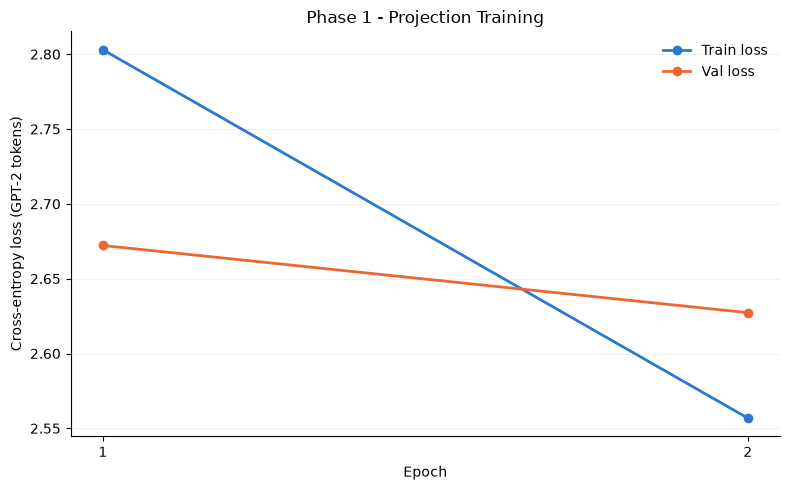

In [12]:
phase1_ckpt = torch.load(PHASE1_CKPT_PATH, map_location=device)
model.load_state_dict(phase1_ckpt["model_state"])

phase1_val_loss = validate(model, val_loader, LIMIT_VAL_BATCHES)

print(f"Best phase 1 checkpoint: epoch {phase1_ckpt['epoch']} | val loss {phase1_ckpt['val_loss']:.4f}")
print(f"Phase 1 val loss: {phase1_val_loss:.4f} | perplexity {math.exp(phase1_val_loss):.2f}")

def plot_curves(train_losses, val_losses, title, boundaries=()):
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs_range = range(1, len(train_losses) + 1)

    ax.plot(epochs_range, train_losses, color="#2a78d6", linewidth=2, marker="o", markersize=6, label="Train loss")
    ax.plot(epochs_range, val_losses, color="#eb6834", linewidth=2, marker="o", markersize=6, label="Val loss")

    for boundary, label in boundaries:
        ax.axvline(boundary + 0.5, color="#888888", linewidth=1, linestyle="--")
        ax.text(boundary + 0.6, ax.get_ylim()[1], label, color="#555555", fontsize=9, va="top")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss (GPT-2 tokens)")
    ax.set_title(title)
    ax.set_xticks(list(epochs_range))
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)

    plt.tight_layout()
    plt.show()

plot_curves(history_phase1["train_loss"], history_phase1["val_loss"], "Phase 1 - Projection Training")


## 14. Phase 2 - Fine-tune GPT-2 Top Blocks

ViT ❄  Projection ✅  GPT-2 blocks 8–11 + ln_f ✅  GPT-2 blocks 0–7 ❄

The lower blocks keep their general language knowledge; the top blocks adapt to reading the visual prefix and writing caption-style sentences.

AdamW lr 5e-5, continues from the best phase 1 checkpoint.
Best checkpoint → checkpoints/best_gpt2_phase2.pt


In [13]:
PHASE2_CKPT_PATH = CHECKPOINT_DIR / "best_gpt2_phase2.pt"

model.freeze_all()
model.unfreeze_projection()
model.unfreeze_gpt2_top(GPT2_TOP_BLOCKS)

print(f"Trainable: ViT {count_trainable(model.vit):,} | Projection {count_trainable(model.projection):,} | GPT-2 {count_trainable(model.gpt2):,} / {count_parameters(model.gpt2):,}")

phase2_param_groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": LR_PHASE2}]

history_phase2, best_phase2_val_loss = run_training(model, phase2_param_groups, EPOCHS_PHASE2, PHASE2_CKPT_PATH, phase="phase2")


Trainable: ViT 0 | Projection 1,181,184 | GPT-2 28,353,024 / 124,439,808
[phase2] steps/epoch 6951 | total steps 13902 | warmup 695 | trainable params 29,534,208
epoch 1/2 | step 200/6951 | loss 2.7857 | lr 1.4e-05
epoch 1/2 | step 400/6951 | loss 2.6574 | lr 2.9e-05
epoch 1/2 | step 600/6951 | loss 2.4545 | lr 4.3e-05
epoch 1/2 | step 800/6951 | loss 2.5713 | lr 5.0e-05
epoch 1/2 | step 1000/6951 | loss 2.6125 | lr 5.0e-05
epoch 1/2 | step 1200/6951 | loss 2.5516 | lr 5.0e-05
epoch 1/2 | step 1400/6951 | loss 3.0834 | lr 5.0e-05
epoch 1/2 | step 1600/6951 | loss 2.7109 | lr 4.9e-05
epoch 1/2 | step 1800/6951 | loss 2.1976 | lr 4.9e-05
epoch 1/2 | step 2000/6951 | loss 2.5659 | lr 4.9e-05
epoch 1/2 | step 2200/6951 | loss 2.5655 | lr 4.8e-05
epoch 1/2 | step 2400/6951 | loss 2.6420 | lr 4.8e-05
epoch 1/2 | step 2600/6951 | loss 2.4291 | lr 4.7e-05
epoch 1/2 | step 2800/6951 | loss 2.0487 | lr 4.7e-05
epoch 1/2 | step 3000/6951 | loss 2.7679 | lr 4.6e-05
epoch 1/2 | step 3200/6951 | los

## 15. Validate

Reload best_gpt2_phase2.pt
      ↓
Val loss
      ↓
Curves phase 1 → phase 2


Best phase 2 checkpoint: epoch 2 | val loss 2.4105
Phase 2 val loss: 2.4105 | perplexity 11.14
Phase 1 val loss: 2.6273


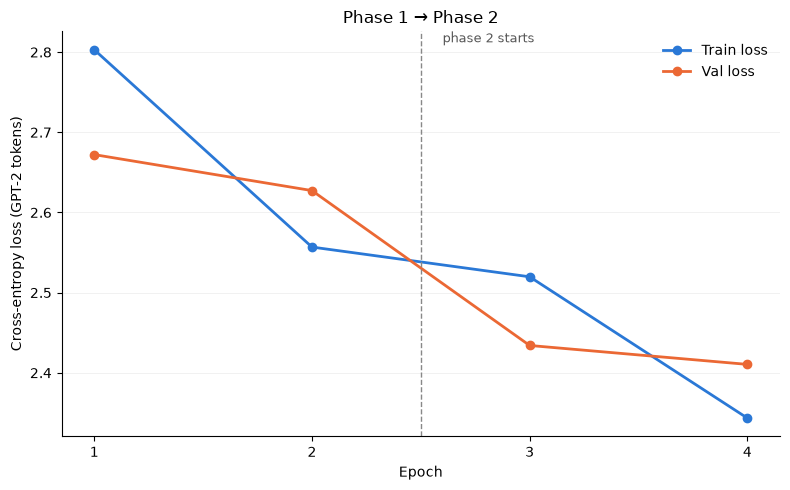

In [14]:
phase2_ckpt = torch.load(PHASE2_CKPT_PATH, map_location=device)
model.load_state_dict(phase2_ckpt["model_state"])

phase2_val_loss = validate(model, val_loader, LIMIT_VAL_BATCHES)

print(f"Best phase 2 checkpoint: epoch {phase2_ckpt['epoch']} | val loss {phase2_ckpt['val_loss']:.4f}")
print(f"Phase 2 val loss: {phase2_val_loss:.4f} | perplexity {math.exp(phase2_val_loss):.2f}")
print(f"Phase 1 val loss: {phase1_val_loss:.4f}")

plot_curves(
    history_phase1["train_loss"] + history_phase2["train_loss"],
    history_phase1["val_loss"] + history_phase2["val_loss"],
    "Phase 1 → Phase 2",
    boundaries=[(len(history_phase1["train_loss"]), "phase 2 starts")],
)


## 16. Phase 3 - Full Fine-tuning

ViT ✅  Projection ✅  GPT-2 ✅

Optional. Everything trains with lr 1e-5 so the pretrained weights move only slightly. Gradient checkpointing on GPT-2 keeps this phase inside 8 GB at BATCH_SIZE 16 (~50 min/epoch on an RTX 4060); it is switched off again afterwards because generation needs the KV cache.

Set EPOCHS_PHASE3 = 0 in section 1 to skip.
Best checkpoint → checkpoints/best_gpt2_phase3.pt


In [15]:
PHASE3_CKPT_PATH = CHECKPOINT_DIR / "best_gpt2_phase3.pt"

model.freeze_all()
model.unfreeze_projection()
model.unfreeze_gpt2()
model.unfreeze_vit()

print(f"Trainable: {count_trainable(model):,} / {count_parameters(model):,}")

model.gpt2.gradient_checkpointing_enable()

phase3_param_groups = [{"params": [p for p in model.parameters() if p.requires_grad], "lr": LR_PHASE3}]

history_phase3, best_phase3_val_loss = run_training(model, phase3_param_groups, EPOCHS_PHASE3, PHASE3_CKPT_PATH, phase="phase3")

model.gpt2.gradient_checkpointing_disable()
model.gpt2.config.use_cache = True


Trainable: 211,419,648 / 211,419,648
[phase3] steps/epoch 6951 | total steps 6951 | warmup 347 | trainable params 211,419,648


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
C:\Users\vishe\AppData\Local\Temp\ipykernel_28680\3272441765.py:25: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


epoch 1/1 | step 200/6951 | loss 2.3550 | lr 5.8e-06
epoch 1/1 | step 400/6951 | loss 2.0848 | lr 1.0e-05
epoch 1/1 | step 600/6951 | loss 2.1699 | lr 1.0e-05
epoch 1/1 | step 800/6951 | loss 2.5770 | lr 9.9e-06
epoch 1/1 | step 1000/6951 | loss 2.3966 | lr 9.8e-06
epoch 1/1 | step 1200/6951 | loss 2.2553 | lr 9.6e-06
epoch 1/1 | step 1400/6951 | loss 2.2672 | lr 9.4e-06
epoch 1/1 | step 1600/6951 | loss 2.2340 | lr 9.1e-06
epoch 1/1 | step 1800/6951 | loss 1.9195 | lr 8.9e-06
epoch 1/1 | step 2000/6951 | loss 2.0105 | lr 8.5e-06
epoch 1/1 | step 2200/6951 | loss 2.3096 | lr 8.2e-06
epoch 1/1 | step 2400/6951 | loss 2.3356 | lr 7.8e-06
epoch 1/1 | step 2600/6951 | loss 2.5322 | lr 7.4e-06
epoch 1/1 | step 2800/6951 | loss 2.3778 | lr 7.0e-06
epoch 1/1 | step 3000/6951 | loss 2.3153 | lr 6.5e-06
epoch 1/1 | step 3200/6951 | loss 2.3137 | lr 6.1e-06
epoch 1/1 | step 3400/6951 | loss 1.9698 | lr 5.6e-06
epoch 1/1 | step 3600/6951 | loss 2.4072 | lr 5.1e-06
epoch 1/1 | step 3800/6951 | los

## 17. Validate

Reload the best checkpoint of the last phase that ran
      ↓
Val loss
      ↓
Curves across all phases


Phases run: ['phase1', 'phase2', 'phase3']
Best phase: phase3 | epoch 1 | val loss 2.3656
Final val loss: 2.3656 | perplexity 10.65


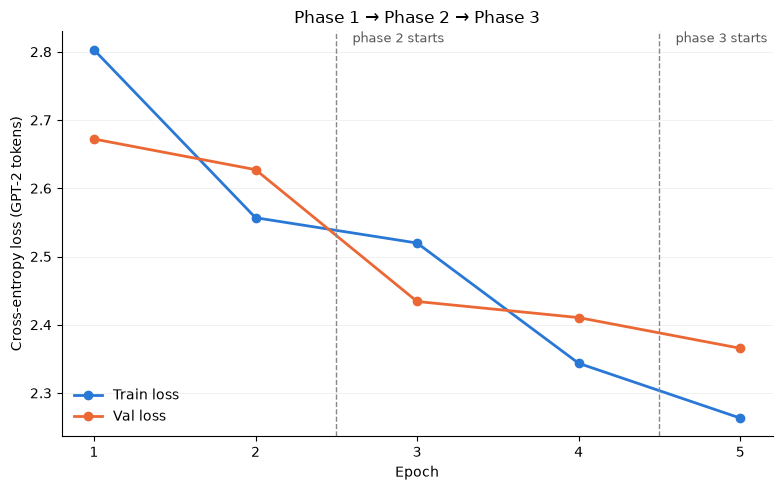

In [16]:
phase_checkpoints = {
    "phase1": (best_phase1_val_loss, PHASE1_CKPT_PATH),
    "phase2": (best_phase2_val_loss, PHASE2_CKPT_PATH),
    "phase3": (best_phase3_val_loss, PHASE3_CKPT_PATH),
}
completed_phases = {name: entry for name, entry in phase_checkpoints.items() if entry[1].exists()}
best_phase = min(completed_phases, key=lambda name: completed_phases[name][0])
best_val_loss, best_ckpt_path = completed_phases[best_phase]

best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state"])

final_val_loss = validate(model, val_loader, LIMIT_VAL_BATCHES)

print(f"Phases run: {list(completed_phases)}")
print(f"Best phase: {best_phase} | epoch {best_ckpt['epoch']} | val loss {best_ckpt['val_loss']:.4f}")
print(f"Final val loss: {final_val_loss:.4f} | perplexity {math.exp(final_val_loss):.2f}")

boundaries = [(len(history_phase1["train_loss"]), "phase 2 starts")]
if history_phase3["train_loss"]:
    boundaries.append((len(history_phase1["train_loss"]) + len(history_phase2["train_loss"]), "phase 3 starts"))

plot_curves(
    history_phase1["train_loss"] + history_phase2["train_loss"] + history_phase3["train_loss"],
    history_phase1["val_loss"] + history_phase2["val_loss"] + history_phase3["val_loss"],
    "Phase 1 → Phase 2 → Phase 3",
    boundaries=boundaries,
)


## 18. Generate Captions

Visual prefix → `gpt2.generate(inputs_embeds=...)`

Greedy → argmax at every step
Beam search → NUM_BEAMS = 5, `no_repeat_ngram_size` = 3, `early_stopping`

Generation stops at `<|endoftext|>` or MAX_NEW_TOKENS. The first-token distribution from section 11 is shown again for the same image.


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


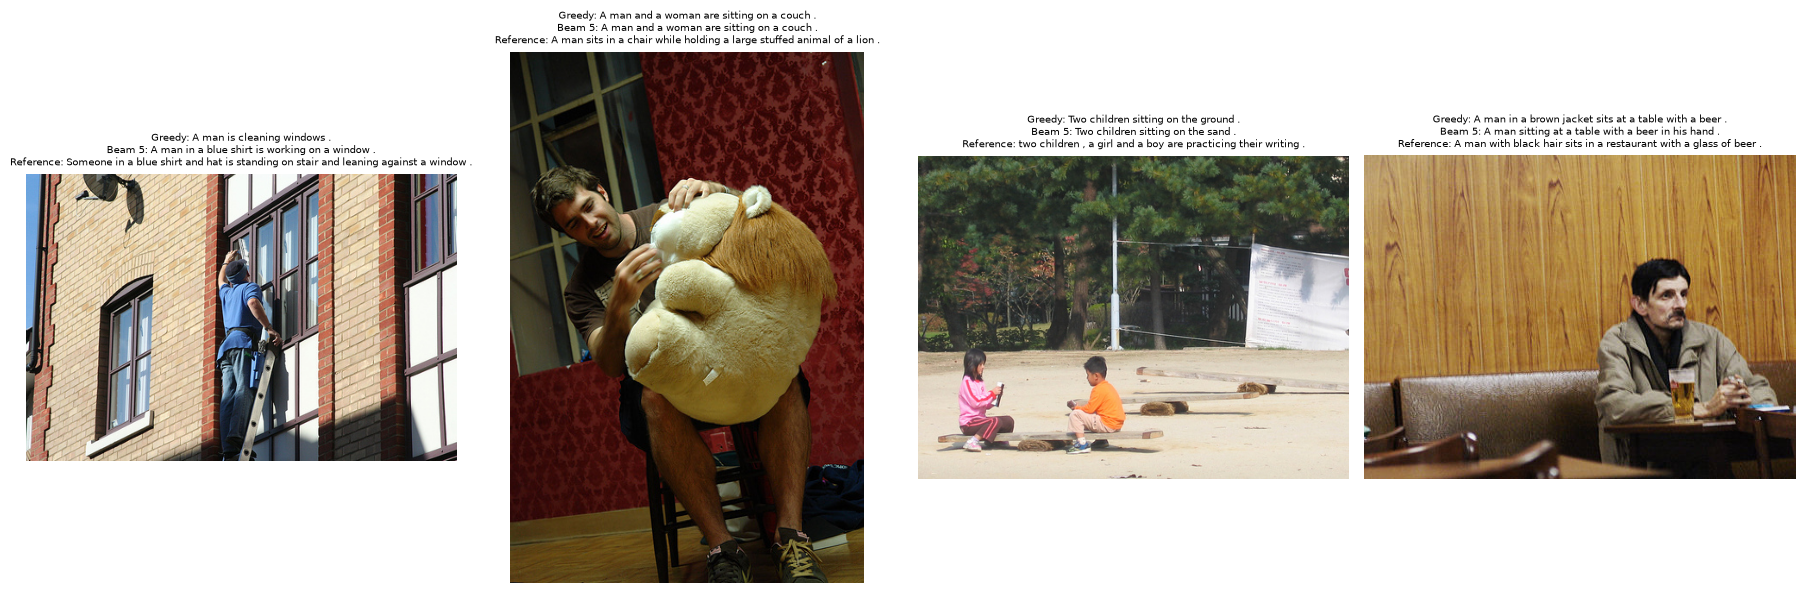

Image: 1000344755.jpg
Top-10 first-token probabilities after training:


,token,probability
0,'A',0.8197
1,'Man',0.0561
2,'An',0.0262
3,'The',0.0197
4,'a',0.0113
5,'Work',0.0103
6,'This',0.0101
7,'Construction',0.0051
8,'Two',0.0044
9,'Someone',0.0043


In [17]:
@torch.no_grad()
def generate_captions(model, images, num_beams=1, max_new_tokens=MAX_NEW_TOKENS):
    model.eval()
    prefix = model.encode_images(images.to(device))
    prefix_mask = torch.ones(prefix.shape[:2], dtype=torch.long, device=device)

    generate_kwargs = dict(
        inputs_embeds=prefix,
        attention_mask=prefix_mask,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        num_beams=num_beams,
        no_repeat_ngram_size=NO_REPEAT_NGRAM,
        eos_token_id=EOS_ID,
        pad_token_id=PAD_ID,
    )
    if num_beams > 1:
        generate_kwargs["early_stopping"] = True

    output_ids = model.gpt2.generate(**generate_kwargs)
    return [tokenizer.decode(ids, skip_special_tokens=True).strip() for ids in output_ids]

greedy_captions = generate_captions(model, sample_images, num_beams=1)
beam_captions = generate_captions(model, sample_images, num_beams=NUM_BEAMS)

fig, axes = plt.subplots(1, len(sample_pil_images), figsize=(18, 6))
for idx, ax in enumerate(axes):
    ax.imshow(sample_pil_images[idx])
    ax.set_title(
        f"Greedy: {greedy_captions[idx]}\n"
        f"Beam {NUM_BEAMS}: {beam_captions[idx]}\n"
        f"Reference: {sample_rows.loc[idx, 'caption']}",
        fontsize=7,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Image: {sample_rows.loc[0, 'image']}")
print("Top-10 first-token probabilities after training:")
display(first_token_distribution(model, sample_images[0]))


## 19. Evaluate

Same 500 unique test images and references as Notebook 05, so BLEU is directly comparable across all models.

Greedy and beam-5 are both scored. Val loss / perplexity for the GPT-2 rows are per BPE token and cannot be compared with the word-level rows above them.


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


,val_loss,perplexity,BLEU-1,BLEU-2,BLEU-3,BLEU-4
Scratch ViT,3.0184,20.4586,0.4904,0.2766,0.1616,0.1005
Frozen ViT + Decoder,2.7380,15.4565,0.6623,0.4671,0.3252,0.2267
Fine-tuned ViT + Decoder,2.6742,14.5012,0.6790,0.4916,0.3528,0.2537
ViT + GPT-2 (greedy),2.3656,10.6499,0.6901,0.4892,0.3449,0.2445
ViT + GPT-2 (beam 5),2.3656,10.6499,0.7103,0.5156,0.3725,0.2684


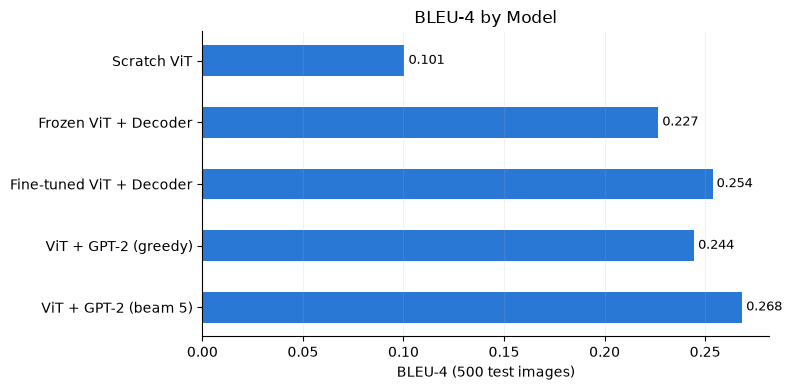

In [18]:
def tokenize(text):
    return text.lower().strip().split()

def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1))

def corpus_bleu(hypotheses, references_list, max_n=4):
    clipped = [0] * max_n
    totals = [0] * max_n
    hyp_len_sum = 0
    ref_len_sum = 0

    for hyp, refs in zip(hypotheses, references_list):
        hyp_tokens = tokenize(hyp)
        ref_tokens_list = [tokenize(ref) for ref in refs]

        hyp_len_sum += len(hyp_tokens)
        ref_len_sum += min((len(r) for r in ref_tokens_list), key=lambda l: (abs(l - len(hyp_tokens)), l))

        for n in range(1, max_n + 1):
            hyp_counts = ngram_counts(hyp_tokens, n)
            max_ref_counts = Counter()
            for ref_tokens in ref_tokens_list:
                for gram, count in ngram_counts(ref_tokens, n).items():
                    max_ref_counts[gram] = max(max_ref_counts[gram], count)
            clipped[n - 1] += sum(min(count, max_ref_counts[gram]) for gram, count in hyp_counts.items())
            totals[n - 1] += max(len(hyp_tokens) - n + 1, 0)

    brevity_penalty = 1.0 if hyp_len_sum > ref_len_sum else math.exp(1 - ref_len_sum / max(hyp_len_sum, 1))

    scores = {}
    for n in range(1, max_n + 1):
        precisions = [(clipped[i] if clipped[i] > 0 else 0.1) / max(totals[i], 1) for i in range(n)]
        scores[f"BLEU-{n}"] = brevity_penalty * math.exp(sum(math.log(p) for p in precisions) / n)
    return scores

eval_df = test_df.drop_duplicates(subset="image").head(EVAL_NUM_IMAGES).reset_index(drop=True)
references_by_image = test_df.groupby("image")["caption"].apply(lambda s: [str(c) for c in s])
eval_references = [references_by_image[image] for image in eval_df["image"]]

def generate_for_paths(model, image_paths, num_beams):
    loader = DataLoader(ImageDataset(image_paths, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=EFFECTIVE_NUM_WORKERS)
    hypotheses = []
    for batch in loader:
        hypotheses.extend(generate_captions(model, batch, num_beams=num_beams))
    return hypotheses

results = dict(previous_results)
for label, num_beams in [("ViT + GPT-2 (greedy)", 1), (f"ViT + GPT-2 (beam {NUM_BEAMS})", NUM_BEAMS)]:
    hypotheses = generate_for_paths(model, eval_df["image_path"], num_beams=num_beams)
    results[label] = {"val_loss": final_val_loss, "perplexity": math.exp(final_val_loss), **corpus_bleu(hypotheses, eval_references)}

results_df = pd.DataFrame(results).T.round(4)
display(results_df)

fig, ax = plt.subplots(figsize=(8, 4))
model_names = list(results_df.index)
bleu4 = results_df["BLEU-4"].tolist()
bars = ax.barh(model_names, bleu4, color="#2a78d6", height=0.5)
for bar, value in zip(bars, bleu4):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=9)
ax.set_xlabel("BLEU-4 (500 test images)")
ax.set_title("BLEU-4 by Model")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25, linewidth=0.5)
plt.tight_layout()
plt.show()


## 20. Save Best Model

Weights of the best phase + tokenizer name + generation settings + all comparison metrics in one file:
src/models/vit_gpt2_captioner.pt (~850 MB)


In [19]:
FINAL_MODEL_PATH = MODEL_DIR / "vit_gpt2_captioner.pt"

torch.save(
    {
        "model_state": model.state_dict(),
        "best_phase": best_phase,
        "best_val_loss": best_val_loss,
        "results": results,
        "config": {
            "vit_model_name": VIT_MODEL_NAME,
            "gpt2_model_name": GPT2_MODEL_NAME,
            "img_size": IMG_SIZE,
            "image_mean": IMAGE_MEAN,
            "image_std": IMAGE_STD,
            "prefix_len": PREFIX_LEN,
            "dropout": DROPOUT,
            "max_tokens": MAX_TOKENS,
            "num_beams": NUM_BEAMS,
            "max_new_tokens": MAX_NEW_TOKENS,
            "no_repeat_ngram": NO_REPEAT_NGRAM,
        },
    },
    FINAL_MODEL_PATH,
)

print(f"Best phase: {best_phase} | val loss {best_val_loss:.4f}")
print(f"Saved: {FINAL_MODEL_PATH} ({FINAL_MODEL_PATH.stat().st_size / 1e6:.0f} MB)")


Best phase: phase3 | val loss 2.3656
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\models\vit_gpt2_captioner.pt (846 MB)
